# Quick start: East Sea daily surface fields, 2023–2025

This notebook shows how little it takes to go from the published Parquet
file to a plot. It uses only `measurements_wide.parquet` from the Zenodo
record ([10.5281/zenodo.22069105](https://doi.org/10.5281/zenodo.22069105)):
one row per `(time, latitude, longitude)`, one column per variable.

All aggregation is done by DuckDB *directly on the Parquet file*, so the
43.7 M rows are never loaded into memory — the notebook runs comfortably on
a laptop.

Requirements: `duckdb`, `pandas`, `matplotlib`, `requests`.

In [1]:
from pathlib import Path

import duckdb
import matplotlib.pyplot as plt
import pandas as pd
import requests

ZENODO_URL = "https://zenodo.org/api/records/22069105/files/measurements_wide.parquet/content"

# Use the local pipeline output if this notebook is run inside the repo,
# otherwise download the published file next to the notebook (~426 MB).
candidates = [Path("../data/parquet/measurements_wide.parquet"), Path("measurements_wide.parquet")]
PARQUET = next((p for p in candidates if p.exists()), None)

if PARQUET is None:
    PARQUET = Path("measurements_wide.parquet")
    with requests.get(ZENODO_URL, stream=True, timeout=60) as r:
        r.raise_for_status()
        with open(PARQUET, "wb") as f:
            for chunk in r.iter_content(chunk_size=1 << 20):
                f.write(chunk)

print(f"Using {PARQUET} ({PARQUET.stat().st_size / 1e6:.0f} MB)")

Using ../data/parquet/measurements_wide.parquet (426 MB)


## What is in the file

In [2]:
con = duckdb.connect()
con.execute(f"CREATE VIEW wide AS SELECT * FROM read_parquet('{PARQUET}')")

con.sql("""
    SELECT
        COUNT(*)                          AS rows,
        COUNT(DISTINCT time)              AS days,
        COUNT(DISTINCT (latitude, longitude)) AS grid_points,
        MIN(time)::DATE                   AS first_day,
        MAX(time)::DATE                   AS last_day,
        ROUND(MIN(longitude), 2)          AS lon_min,
        ROUND(MAX(longitude), 2)          AS lon_max,
        ROUND(MIN(latitude), 2)           AS lat_min,
        ROUND(MAX(latitude), 2)           AS lat_max
    FROM wide
""").df()

,rows,days,grid_points,first_day,last_day,lon_min,lon_max,lat_min,lat_max
0,43665736,1096,39841,2023-01-01,2025-12-31,102.33,122.08,-3.17,25.5


In [3]:
con.sql("SELECT * FROM wide LIMIT 5").df()

,time,latitude,longitude,thetao,so,uo,vo
0,2023-01-04,1.916667,110.500000,28.667959,27.732170,0.109867,0.004883
1,2023-01-04,2.416667,104.750000,27.570025,32.082583,0.111087,-0.473037
2,2023-01-04,2.666667,111.416664,29.376232,24.893948,0.071413,0.084231
3,2023-01-04,2.833333,107.166664,27.726035,32.435072,0.122684,-0.318003
4,2023-01-04,3.000000,106.166664,27.738487,32.316050,0.159917,-0.357067


## 1. Basin-mean sea surface temperature, month by month

One number per month: the average `thetao` over every grid cell and every
day in that month.

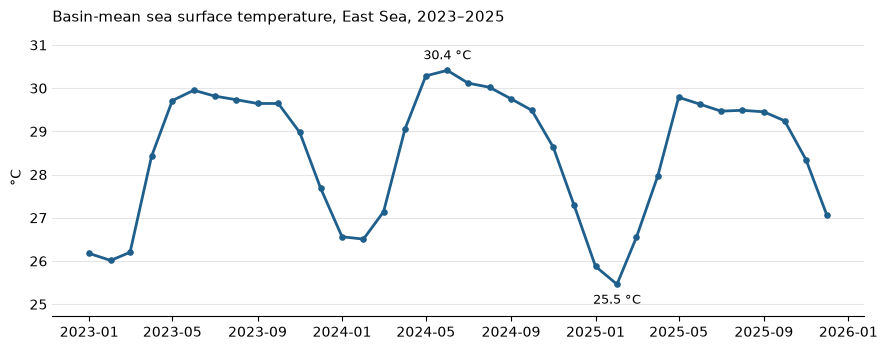

In [4]:
monthly = con.sql("""
    SELECT date_trunc('month', time)::DATE AS month, AVG(thetao) AS sst
    FROM wide
    GROUP BY month
    ORDER BY month
""").df()

fig, ax = plt.subplots(figsize=(9, 3.6))
ax.plot(monthly["month"], monthly["sst"], color="#1f5f8b", linewidth=2)
ax.scatter(monthly["month"], monthly["sst"], color="#1f5f8b", s=14, zorder=3)

hi = monthly.loc[monthly["sst"].idxmax()]
lo = monthly.loc[monthly["sst"].idxmin()]
ax.annotate(f"{hi.sst:.1f} °C", (hi.month, hi.sst), xytext=(0, 8), textcoords="offset points", ha="center", fontsize=9)
ax.annotate(f"{lo.sst:.1f} °C", (lo.month, lo.sst), xytext=(0, -14), textcoords="offset points", ha="center", fontsize=9)

ax.margins(y=0.15)  # room for the two annotations
ax.set_title("Basin-mean sea surface temperature, East Sea, 2023–2025", loc="left", fontsize=11, pad=12)
ax.set_ylabel("°C")
ax.grid(axis="y", color="#e5e5e5", linewidth=0.8)
for side in ("top", "right", "left"):
    ax.spines[side].set_visible(False)
ax.tick_params(axis="y", length=0)
plt.tight_layout()
plt.show()

## 2. Where is it warm? Three-year mean SST per grid cell

Averaging over time collapses 43.7 M rows to one value per grid point
(39,841 of them). Because the grid is regular (0.0833°), a pivot to a 2-D
array is enough to draw it as an image — no geospatial library needed.
Cells outside the IHO "Bien Dong" polygon are simply absent (white).

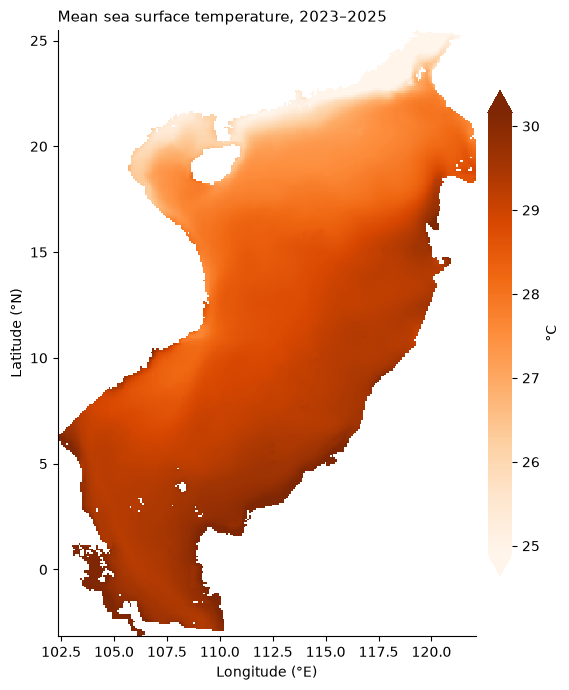

In [5]:
def field(expr: str) -> pd.DataFrame:
    """Time-mean of `expr` per grid cell, pivoted to a lat x lon array."""
    df = con.sql(f"""
        SELECT latitude, longitude, AVG({expr}) AS v
        FROM wide
        GROUP BY latitude, longitude
    """).df()
    return df.pivot(index="latitude", columns="longitude", values="v")


def draw_field(grid: pd.DataFrame, title: str, label: str, cmap: str):
    extent = [grid.columns.min(), grid.columns.max(), grid.index.min(), grid.index.max()]
    # Clip the colour scale to the 2nd-98th percentile so a few extreme
    # cells (straits, river mouths) do not wash out the rest of the basin.
    vmin, vmax = grid.stack().quantile([0.02, 0.98])
    fig, ax = plt.subplots(figsize=(6.5, 7))
    im = ax.imshow(grid.values, origin="lower", extent=extent, cmap=cmap, aspect="equal",
                   interpolation="nearest", vmin=vmin, vmax=vmax)
    cb = fig.colorbar(im, ax=ax, shrink=0.8, pad=0.02, extend="both")
    cb.set_label(label)
    cb.outline.set_visible(False)
    ax.set_title(title, loc="left", fontsize=11)
    ax.set_xlabel("Longitude (°E)")
    ax.set_ylabel("Latitude (°N)")
    for side in ("top", "right"):
        ax.spines[side].set_visible(False)
    plt.tight_layout()
    plt.show()


sst_mean = field("thetao")
draw_field(sst_mean, "Mean sea surface temperature, 2023–2025", "°C", "Oranges")

## 3. Mean surface current speed

`uo` and `vo` are the eastward and northward components; speed is their
vector magnitude. The mean speed is computed per day and cell first, then
averaged over time, so opposing currents on different days do not cancel
out.

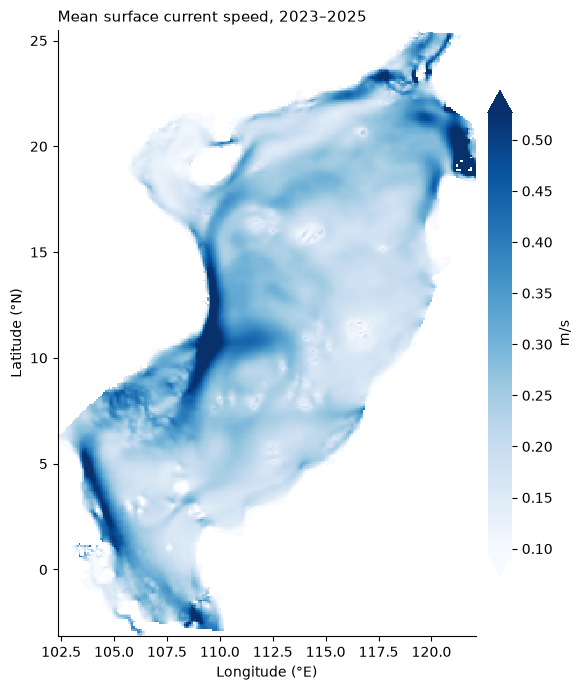

In [6]:
speed_mean = field("sqrt(uo * uo + vo * vo)")
draw_field(speed_mean, "Mean surface current speed, 2023–2025", "m/s", "Blues")

## Going further

Everything above is a `GROUP BY` on one Parquet file. Some obvious next
steps with the same file:

- seasonal cycle per year (`GROUP BY year, month`) to compare 2023 / 2024 / 2025;
- a time series at one point (`WHERE latitude = … AND longitude = …`);
- the long-format files (`measurements_long_<variable>.parquet`) if you
  only need one variable and want the smallest download.

See `data/parquet/README.md` in the repository for the full schema.